# Cue effectiveness

During the VRT test phase, participants see film cue images interleaved with foil images. Each cue is a still from one of the 11 clips they studied. The core question: how often does a cue trigger recall of the matching clip?

We define a cue as "effective" when the next recall event after the cue matches the cue's clip number, with the caveat that foil images clear any pending cue. This means a foil appearing between a cue and a recall breaks the cue-recall link. The interleaved event sequence (`recall_items` + `recall_types`) preserves this temporal structure, so we can compute cue effectiveness directly from the event stream.

In [1]:
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np

from jaxcmr.helpers import find_project_root, load_data

warnings.filterwarnings("ignore")

In [2]:
run_tag = "VRT_cue_effectiveness"
data_path = "data/VRT_clips.h5"
figure_dir = "results/figures"
figure_str = run_tag

In [3]:
project_root = find_project_root()
figure_dir = os.path.join(project_root, figure_dir)
data_path = os.path.join(project_root, data_path)
data = load_data(data_path)

task = np.array(data["task"]).reshape(-1)
condition = np.array(data["condition"]).reshape(-1)
intervention = np.array(data["intervention"]).reshape(-1)
subjects = np.array(data["subject"]).reshape(-1)
recall_items = np.array(data["recall_items"])
recall_types = np.array(data["recall_types"])

n_trials = recall_items.shape[0]
print(f"Loaded {n_trials} trials")

Loaded 240 trials


## Computing cue effectiveness from the event stream

We walk each trial's interleaved event sequence one event at a time. When we encounter a cue (type=1), we record its clip number as the pending cue. A foil (type=3) or an unclassified utterance (type=4) clears the pending cue. When a recall event (type=2) arrives, we check whether its clip number matches the pending cue. If so, that's a cue hit; either way, the cue is consumed.

This yields two per-trial counts: the number of cue presentations and the number of cue hits. The hit rate is the ratio. Note that each trial has a fixed number of cue presentations (22 per trial from the QC snapshot), so the denominator is constant across trials.

In [4]:
def compute_cue_effectiveness(recall_items, recall_types):
    """Compute per-trial cue hit counts and total cue counts.

    A cue is effective when the next recall after it matches the cue's
    clip number. Foils (type=3) and unclassified utterances (type=4)
    clear the pending cue, so either one between a cue and a recall
    breaks the link.

    Returns (hits, total_cues) arrays of shape [n_trials].
    """
    n_trials = recall_items.shape[0]
    hits = np.zeros(n_trials, dtype=int)
    total_cues = np.zeros(n_trials, dtype=int)

    for t in range(n_trials):
        pending_cue = 0
        for e in range(recall_items.shape[1]):
            etype = int(recall_types[t, e])
            item = int(recall_items[t, e])
            if etype == 0:
                break
            elif etype == 1:  # cue
                total_cues[t] += 1
                pending_cue = item
            elif etype == 3:  # foil clears cue
                pending_cue = 0
            elif etype == 2:  # recall
                if pending_cue > 0 and item == pending_cue:
                    hits[t] += 1
                pending_cue = 0
            elif etype == 4:  # unclassified clears cue
                pending_cue = 0

    return hits, total_cues


hits, total_cues = compute_cue_effectiveness(recall_items, recall_types)
hit_rate = hits / np.maximum(total_cues, 1)

print(f"Cues per trial: {total_cues.mean():.1f} (all trials = {total_cues[0]})")
print(f"Mean cue hits:  {hits.mean():.2f} (SD={hits.std():.2f})")
print(f"Mean hit rate:  {hit_rate.mean():.3f} (SD={hit_rate.std():.3f})")

Cues per trial: 22.0 (all trials = 22)
Mean cue hits:  8.18 (SD=6.19)
Mean hit rate:  0.372 (SD=0.281)


## Plotting helpers

Bar chart of per-subject mean cue hit rate with 95% CI error bars. Since each subject contributes one trial, per-subject means are just the trial values, but we keep the `subject_means` pattern for consistency with future multi-trial extensions.

In [5]:
def subject_means(values, mask, subjects):
    unique_subs = np.unique(subjects[mask])
    return np.array([values[mask & (subjects == s)].mean() for s in unique_subs])


def ci95(values):
    m = values.mean()
    se = values.std(ddof=1) / np.sqrt(len(values))
    return m, 1.96 * se


def plot_cue_effectiveness(masks, labels, contrast_name, ax=None):
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(6, 4))

    x = np.arange(len(labels))
    width = 0.6

    for i, (mask, label) in enumerate(zip(masks, labels)):
        sm = subject_means(hit_rate, mask, subjects)
        m, e = ci95(sm)
        ax.bar(x[i], m, width, yerr=e, color="steelblue",
               capsize=4, error_kw={"color": "black"})
        print(f"{label}: n={int(mask.sum())}, hit_rate={m:.3f} +/- {e:.3f}")

    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylabel("Cue hit rate")
    ax.set_ylim(0, 1)
    ax.set_title(contrast_name)
    return ax


def save_figure(fig_dir, fig_str, suffix=None):
    if not fig_str:
        plt.show()
        return
    os.makedirs(fig_dir, exist_ok=True)
    suffix_str = f"_{suffix}" if suffix else ""
    path = os.path.join(fig_dir, f"{fig_str}{suffix_str}.png")
    plt.savefig(path, bbox_inches="tight", dpi=600)
    plt.show()

## Task (involuntary vs voluntary)

Involuntary recall is cue-driven by definition. If voluntary recall can also exploit cues, effectiveness rates should be comparable. A large gap would suggest that voluntary recall operates more independently of external cues.

Involuntary: n=120, hit_rate=0.396 +/- 0.048
Voluntary: n=120, hit_rate=0.348 +/- 0.052


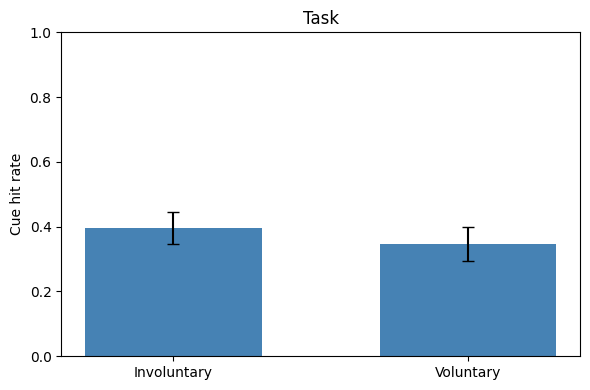

In [6]:
masks = [task == 1, task == 2]
labels = ["Involuntary", "Voluntary"]

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
plot_cue_effectiveness(masks, labels, "Task", ax=ax)
plt.tight_layout()
save_figure(figure_dir, figure_str, suffix="task")

## Condition (emotional vs neutral)

Emotional: n=120, hit_rate=0.302 +/- 0.045
Neutral: n=120, hit_rate=0.442 +/- 0.052


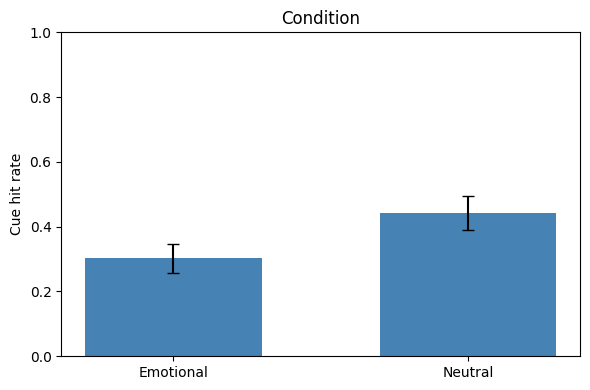

In [7]:
masks = [condition == 1, condition == 2]
labels = ["Emotional", "Neutral"]

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
plot_cue_effectiveness(masks, labels, "Condition", ax=ax)
plt.tight_layout()
save_figure(figure_dir, figure_str, suffix="condition")

## Intervention (podcast vs Tetris)

Podcast: n=120, hit_rate=0.387 +/- 0.052
Tetris: n=120, hit_rate=0.357 +/- 0.049


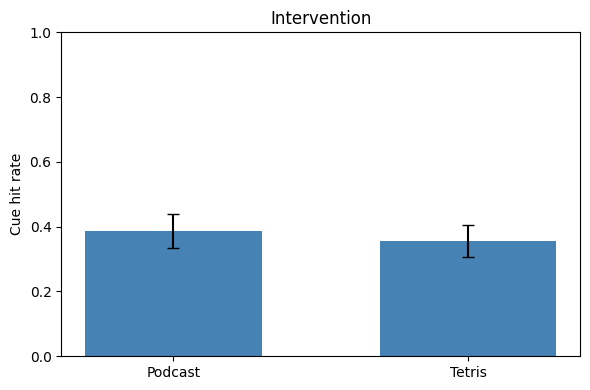

In [8]:
masks = [intervention == 0, intervention == 1]
labels = ["Podcast", "Tetris"]

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
plot_cue_effectiveness(masks, labels, "Intervention", ax=ax)
plt.tight_layout()
save_figure(figure_dir, figure_str, suffix="intervention")

## Task x Condition

Invol+Emot: n=60, hit_rate=0.304 +/- 0.053
Invol+Neut: n=60, hit_rate=0.488 +/- 0.074
Vol+Emot: n=60, hit_rate=0.300 +/- 0.074
Vol+Neut: n=60, hit_rate=0.396 +/- 0.073


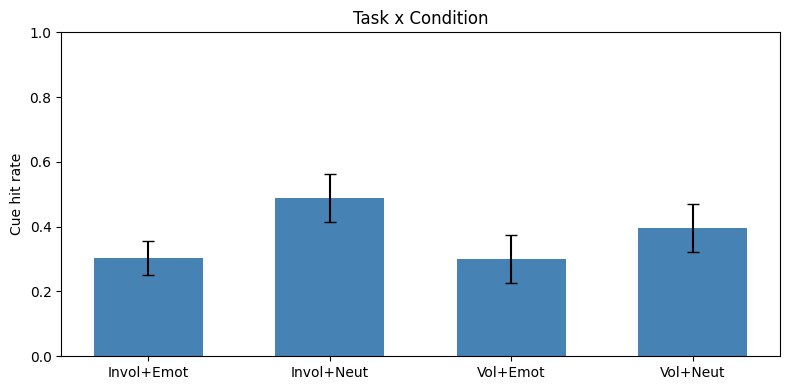

In [9]:
masks = [
    (task == 1) & (condition == 1),
    (task == 1) & (condition == 2),
    (task == 2) & (condition == 1),
    (task == 2) & (condition == 2),
]
labels = ["Invol+Emot", "Invol+Neut", "Vol+Emot", "Vol+Neut"]

fig, ax = plt.subplots(1, 1, figsize=(8, 4))
plot_cue_effectiveness(masks, labels, "Task x Condition", ax=ax)
plt.tight_layout()
save_figure(figure_dir, figure_str, suffix="task_condition")

## Task x Intervention

Invol+Podcast: n=60, hit_rate=0.409 +/- 0.069
Invol+Tetris: n=60, hit_rate=0.383 +/- 0.067
Vol+Podcast: n=60, hit_rate=0.365 +/- 0.077
Vol+Tetris: n=60, hit_rate=0.331 +/- 0.072


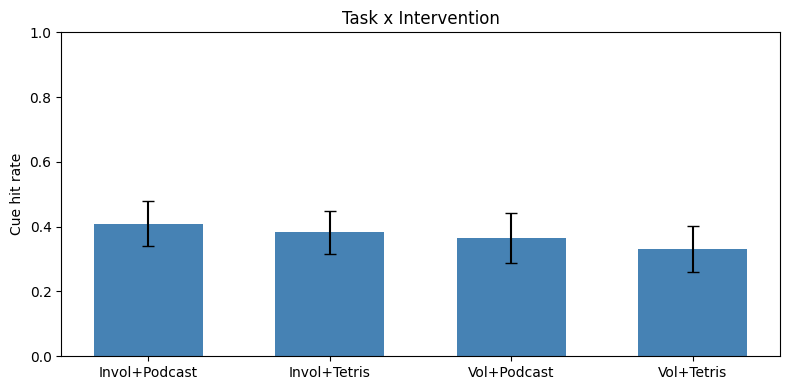

In [10]:
masks = [
    (task == 1) & (intervention == 0),
    (task == 1) & (intervention == 1),
    (task == 2) & (intervention == 0),
    (task == 2) & (intervention == 1),
]
labels = ["Invol+Podcast", "Invol+Tetris", "Vol+Podcast", "Vol+Tetris"]

fig, ax = plt.subplots(1, 1, figsize=(8, 4))
plot_cue_effectiveness(masks, labels, "Task x Intervention", ax=ax)
plt.tight_layout()
save_figure(figure_dir, figure_str, suffix="task_intervention")

## Condition x Intervention

Emot+Podcast: n=60, hit_rate=0.302 +/- 0.068
Emot+Tetris: n=60, hit_rate=0.302 +/- 0.060
Neut+Podcast: n=60, hit_rate=0.472 +/- 0.072
Neut+Tetris: n=60, hit_rate=0.412 +/- 0.076


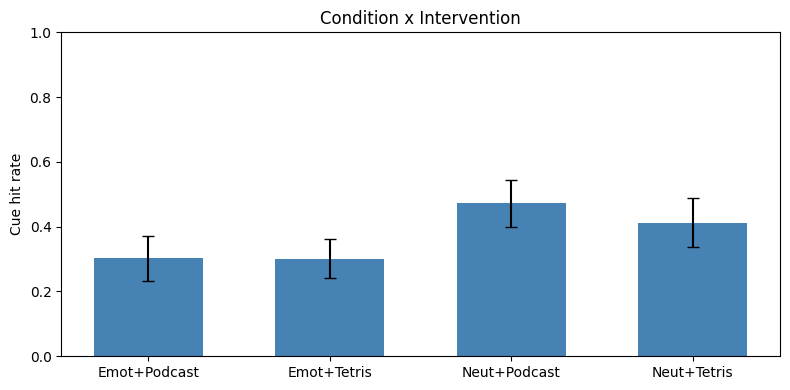

In [11]:
masks = [
    (condition == 1) & (intervention == 0),
    (condition == 1) & (intervention == 1),
    (condition == 2) & (intervention == 0),
    (condition == 2) & (intervention == 1),
]
labels = ["Emot+Podcast", "Emot+Tetris", "Neut+Podcast", "Neut+Tetris"]

fig, ax = plt.subplots(1, 1, figsize=(8, 4))
plot_cue_effectiveness(masks, labels, "Condition x Intervention", ax=ax)
plt.tight_layout()
save_figure(figure_dir, figure_str, suffix="condition_intervention")

## Sensitivity analysis: metric choice and the denominator problem

Misra, McConnell & Talmi analysed the same dataset and reported that "cue-memory match percentages" were *higher* for negative films than neutral films — the opposite direction from our finding above. The discrepancy turns on what goes in the denominator.

Our metric divides by the **number of cues** (22 per trial, constant). Their metric divides by the **number of memories** (total button presses, which varies by condition). Neutral participants produce more memories (~20 vs ~14 for emotional), so a variable denominator penalises neutral even when it has more absolute matches.

Their analysis also differs in two structural ways: foils do **not** clear the pending cue, and **all** button presses (including repeats) contribute — not just the unique-first recalls stored in `recalls`.

Below we recompute cue effectiveness using two variants of their per-memory metric, still with our human-coded clip labels, to test whether the denominator alone is sufficient to flip the direction.

In [12]:
def compute_match_percentage_consumed(recall_items, recall_types):
    """Per-memory match percentage: no foil clearing, cue consumed after first memory.

    Mirrors the old pipeline logic: a cue (type=1) sets the pending cue,
    foils are ignored, and the first memory (type=2) consumes the cue.
    Unclassified utterances (type=4) also consume the pending cue.
    A match = memory clip == pending cue clip.

    Returns (matches, total_memories) arrays of shape [n_trials].
    """
    n_trials = recall_items.shape[0]
    matches = np.zeros(n_trials, dtype=int)
    total_memories = np.zeros(n_trials, dtype=int)

    for t in range(n_trials):
        pending_cue = 0
        for e in range(recall_items.shape[1]):
            etype = int(recall_types[t, e])
            item = int(recall_items[t, e])
            if etype == 0:
                break
            elif etype == 1:  # cue sets pending (no clearing by foils)
                pending_cue = item
            elif etype == 2:  # memory
                total_memories[t] += 1
                if pending_cue > 0 and item == pending_cue:
                    matches[t] += 1
                pending_cue = 0  # consumed after first memory
            elif etype == 4:  # unclassified consumes cue
                pending_cue = 0

    return matches, total_memories


def compute_match_percentage_persistent(recall_items, recall_types):
    """Per-memory match percentage: no foil clearing, cue NOT consumed.

    Most permissive variant: the most recent cue persists until replaced
    by a new cue. Every memory is checked against the current cue.
    Unclassified utterances (type=4) do not clear the cue in this variant.

    Returns (matches, total_memories) arrays of shape [n_trials].
    """
    n_trials = recall_items.shape[0]
    matches = np.zeros(n_trials, dtype=int)
    total_memories = np.zeros(n_trials, dtype=int)

    for t in range(n_trials):
        current_cue = 0
        for e in range(recall_items.shape[1]):
            etype = int(recall_types[t, e])
            item = int(recall_items[t, e])
            if etype == 0:
                break
            elif etype == 1:  # new cue replaces old
                current_cue = item
            elif etype == 2:  # memory — cue NOT consumed
                total_memories[t] += 1
                if current_cue > 0 and item == current_cue:
                    matches[t] += 1
            elif etype == 4:
                pass  # persistent: cue survives

    return matches, total_memories


# Compute both variants.
matches_c, mems_c = compute_match_percentage_consumed(recall_items, recall_types)
pct_consumed = matches_c / np.maximum(mems_c, 1) * 100

matches_p, mems_p = compute_match_percentage_persistent(recall_items, recall_types)
pct_persistent = matches_p / np.maximum(mems_p, 1) * 100

print("Variant 1 — cue consumed after first memory (no foil clearing):")
print(f"  Total memories/trial: {mems_c.mean():.1f}")
print(f"  Matches/trial:        {matches_c.mean():.2f}")
print(f"  Match percentage:     {pct_consumed.mean():.1f}%\n")

print("Variant 2 — cue persistent until replaced (no foil clearing):")
print(f"  Total memories/trial: {mems_p.mean():.1f}")
print(f"  Matches/trial:        {matches_p.mean():.2f}")
print(f"  Match percentage:     {pct_persistent.mean():.1f}%")

Variant 1 — cue consumed after first memory (no foil clearing):
  Total memories/trial: 16.7
  Matches/trial:        8.54
  Match percentage:     53.3%

Variant 2 — cue persistent until replaced (no foil clearing):
  Total memories/trial: 16.7
  Matches/trial:        8.84
  Match percentage:     54.6%


### Condition comparison across all three metrics

The critical test: does the emotional-vs-neutral direction flip when we switch from a per-cue denominator (our metric) to a per-memory denominator (their metric)?

In [13]:
def compare_metrics(metric_values, metric_name, masks, labels):
    """Print per-group means with 95% CIs for a given metric."""
    print(f"  {metric_name}:")
    for mask, label in zip(masks, labels):
        sm = subject_means(metric_values, mask, subjects)
        m, e = ci95(sm)
        print(f"    {label:12s}: {m:.1f}% +/- {e:.1f}%  (n={int(mask.sum())})")


cond_masks = [condition == 1, condition == 2]
cond_labels = ["Emotional", "Neutral"]

print("=== Condition (emotional vs neutral) ===\n")
compare_metrics(hit_rate * 100, "Our metric (hits / 22 cues)", cond_masks, cond_labels)
print()
compare_metrics(pct_consumed, "Variant 1 (matches / memories, cue consumed)", cond_masks, cond_labels)
print()
compare_metrics(pct_persistent, "Variant 2 (matches / memories, cue persistent)", cond_masks, cond_labels)

# Also show the raw counts to understand the denominator effect.
print("\n--- Raw counts by condition ---")
for mask, label in zip(cond_masks, cond_labels):
    m_hits = hits[mask].mean()
    m_mems = mems_c[mask].mean()
    m_mc = matches_c[mask].mean()
    m_mp = matches_p[mask].mean()
    print(f"  {label:12s}: {m_mems:.1f} memories/trial, "
          f"{m_hits:.1f} cue hits (our), "
          f"{m_mc:.1f} matches (v1), "
          f"{m_mp:.1f} matches (v2)")

=== Condition (emotional vs neutral) ===

  Our metric (hits / 22 cues):
    Emotional   : 30.2% +/- 4.5%  (n=120)
    Neutral     : 44.2% +/- 5.2%  (n=120)

  Variant 1 (matches / memories, cue consumed):
    Emotional   : 48.0% +/- 5.7%  (n=120)
    Neutral     : 58.7% +/- 5.9%  (n=120)

  Variant 2 (matches / memories, cue persistent):
    Emotional   : 49.5% +/- 5.6%  (n=120)
    Neutral     : 59.6% +/- 5.7%  (n=120)

--- Raw counts by condition ---
  Emotional   : 15.2 memories/trial, 6.6 cue hits (our), 7.0 matches (v1), 7.4 matches (v2)
  Neutral     : 18.1 memories/trial, 9.7 cue hits (our), 10.1 matches (v1), 10.3 matches (v2)


### Task comparison across all three metrics

Check that the involuntary > voluntary direction holds across all metrics (both our analysis and the paper agree on this).

In [14]:
task_masks = [task == 1, task == 2]
task_labels = ["Involuntary", "Voluntary"]

print("=== Task (involuntary vs voluntary) ===\n")
compare_metrics(hit_rate * 100, "Our metric (hits / 22 cues)", task_masks, task_labels)
print()
compare_metrics(pct_consumed, "Variant 1 (matches / memories, cue consumed)", task_masks, task_labels)
print()
compare_metrics(pct_persistent, "Variant 2 (matches / memories, cue persistent)", task_masks, task_labels)

print("\n--- Raw counts by task ---")
for mask, label in zip(task_masks, task_labels):
    m_mems = mems_c[mask].mean()
    m_hits = hits[mask].mean()
    m_mc = matches_c[mask].mean()
    m_mp = matches_p[mask].mean()
    print(f"  {label:12s}: {m_mems:.1f} memories/trial, "
          f"{m_hits:.1f} cue hits (our), "
          f"{m_mc:.1f} matches (v1), "
          f"{m_mp:.1f} matches (v2)")

=== Task (involuntary vs voluntary) ===

  Our metric (hits / 22 cues):
    Involuntary : 39.6% +/- 4.8%  (n=120)
    Voluntary   : 34.8% +/- 5.2%  (n=120)

  Variant 1 (matches / memories, cue consumed):
    Involuntary : 65.9% +/- 5.3%  (n=120)
    Voluntary   : 40.7% +/- 5.5%  (n=120)

  Variant 2 (matches / memories, cue persistent):
    Involuntary : 66.6% +/- 5.2%  (n=120)
    Voluntary   : 42.6% +/- 5.4%  (n=120)

--- Raw counts by task ---
  Involuntary : 13.6 memories/trial, 8.7 cue hits (our), 9.0 matches (v1), 9.2 matches (v2)
  Voluntary   : 19.8 memories/trial, 7.7 cue hits (our), 8.1 matches (v1), 8.5 matches (v2)


### Summary table

Side-by-side comparison of all three metrics for the key contrasts.

In [15]:
def row(label, mask):
    hr = subject_means(hit_rate * 100, mask, subjects)
    v1 = subject_means(pct_consumed, mask, subjects)
    v2 = subject_means(pct_persistent, mask, subjects)
    return f"| {label:20s} | {hr.mean():5.1f}% | {v1.mean():5.1f}% | {v2.mean():5.1f}% |"


print("| Group                | Ours (hits/cues) | V1 (consumed) | V2 (persistent) |")
print("|----------------------|------------------|---------------|-----------------|")
print(row("Emotional", condition == 1))
print(row("Neutral", condition == 2))
print(row("Involuntary", task == 1))
print(row("Voluntary", task == 2))
print()
print("Direction check:")
e_hr = subject_means(hit_rate * 100, condition == 1, subjects).mean()
n_hr = subject_means(hit_rate * 100, condition == 2, subjects).mean()
e_v1 = subject_means(pct_consumed, condition == 1, subjects).mean()
n_v1 = subject_means(pct_consumed, condition == 2, subjects).mean()
e_v2 = subject_means(pct_persistent, condition == 1, subjects).mean()
n_v2 = subject_means(pct_persistent, condition == 2, subjects).mean()

print(f"  Our metric:    {'Emot > Neut' if e_hr > n_hr else 'Neut > Emot'} ({e_hr:.1f}% vs {n_hr:.1f}%)")
print(f"  V1 (consumed): {'Emot > Neut' if e_v1 > n_v1 else 'Neut > Emot'} ({e_v1:.1f}% vs {n_v1:.1f}%)")
print(f"  V2 (persist):  {'Emot > Neut' if e_v2 > n_v2 else 'Neut > Emot'} ({e_v2:.1f}% vs {n_v2:.1f}%)")

| Group                | Ours (hits/cues) | V1 (consumed) | V2 (persistent) |
|----------------------|------------------|---------------|-----------------|
| Emotional            |  30.2% |  48.0% |  49.5% |
| Neutral              |  44.2% |  58.7% |  59.6% |
| Involuntary          |  39.6% |  65.9% |  66.6% |
| Voluntary            |  34.8% |  40.7% |  42.6% |

Direction check:
  Our metric:    Neut > Emot (30.2% vs 44.2%)
  V1 (consumed): Neut > Emot (48.0% vs 58.7%)
  V2 (persist):  Neut > Emot (49.5% vs 59.6%)
